In [36]:
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
import string

from flonacomldft.utils.diagnostics import avg_windows

from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    load_ag6_image,
    plot_energy_histogram,
)

from flonacomldft.utils.diagnostics import R_hat
import torch
from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file, 
    get_project_path
)

import cmocean.cm as cmo

sns.set()

# science format
science = {
            # Set line widths
            'axes.linewidth' : 1,
            'grid.linewidth' : 1,

            # Remove legend frame
            #'legend.frameon' : False,

            # Always save as 'tight'
            'savefig.bbox' : 'tight',
            'savefig.pad_inches' : 0.05,

            # Use serif fonts
            # 'font.serif' : 'Times',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
    
            # Set y axis
            #'ytick.direction' : 'out',
            #'ytick.major.size' : 3,
            #'ytick.major.width' : 0.5,
            #'ytick.minor.size' : 1.5,
            #'ytick.minor.width' : 0.5,
            #'ytick.minor.visible' : True,
    
            # Set x axis
            #'xtick.direction' : 'out',
            #'xtick.major.size' : 3,
            #'xtick.major.width' : 0.5,
            #'xtick.minor.size' : 1.5,
            #'xtick.minor.width' : 0.5,
            #'xtick.minor.visible' : True
           }

# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

model_colors = dict(zip(['ab-flowMC w.o NP', 'ab-flowMC', 'MD'],
                        ['#0077BB', '#CC3311', '#cdb332']))

sns.color_palette(model_colors.values())


[(0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902)]

In [37]:
def set_plot_figure_1(
    cvs,
    flow_samples,
    accs,
    rhat,
    energies,
    np_predictions,
    isomer,
    colors,
    figsize=(8, 7),
    fontsize=34,
    size_axes_label=34,
    size_tick_label=34,
    size_legend=28,
    linewidth=3,
    markersize=20,
):

    ncols = 4
    nrows = 2
    
    CV1_label, CV2_label, Method = cvs.columns

    sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_tick_label,
                        })   

    # ------ SET FIGURE SIZE ------

    fig, axs = plt.subplots(ncols=ncols, 
                    nrows=nrows, 
                    figsize=(figsize[0]*ncols, figsize[1]*nrows))

    # ------ SET BIG SUPLOT ------

    gs = axs[0, 0].get_gridspec()

    for ax in axs[:2, :2].ravel():
        ax.remove()
    
    axbig = fig.add_subplot(gs[0:, :2])

    # ------ NUMERAL TO SUBPLOT ------

    posx = -0.05
    posy = 1.05

    axbig.text(posx+0.025,
            posy-0.025, 
            string.ascii_uppercase[0], 
            transform=axbig.transAxes, 
            weight='bold',)

    for n, ax in enumerate(axs[:, 2:].ravel()):
        ax.text(posx,
        posy, 
        string.ascii_uppercase[n+1], 
        transform=ax.transAxes, 
        weight='bold')

    # ------ PLOT COLLECTIVE VARIABLES ------

    #sns.kdeplot(
    #    data=flow_samples, x=CV1_label, y=CV2_label, hue='NLL',
    #    #fill=True, common_norm=False, #color="black",
    #    #cmap='autumn',
    #    levels=6, linestyle=':', linewidths=linewidth,
    #    ax=axbig)

    sns.scatterplot(
            data=cvs,
            x=CV1_label, 
            y=CV2_label, 
            hue=Method,
            ax=axbig,
            palette=colors,
            s=markersize*10,
            zorder=2.5,
            marker='o',
            alpha=1,
        )
    
    axbig.set_xlabel(CV1_label)
    axbig.set_ylabel(CV2_label)

    #axbig.spines[['right', 'top']].set_visible(False)

    axbig.xaxis.set_major_locator(plt.MaxNLocator(5))
    axbig.yaxis.set_major_locator(plt.MaxNLocator(6))            

    # ------ PLOT ISOMER IMAGE ------

    l, b, h, w = axs[1][0].get_position().get_points().flatten()
    ax2 = fig.add_axes([-l*0.6, b, w*0.9, h*0.9])
    ax2.imshow(load_ag6_image(isomer))
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_axis_off()

    # ------ PLOT ACCEPTANCE RATIO ------

    for key in accs.keys():
        sns.lineplot(accs[key],
            alpha=0.1,
            color=colors[key],
            linewidth=linewidth*0.5,
            ax=axs[0][2],
            )
        accs_avg = avg_windows(accs[key], 
                               window_size=40, 
                               axis=1)
        sns.lineplot(accs_avg,
            color=colors[key],
            linewidth=linewidth,
            ax=axs[0][2],
            )
    
    axs[0][2].set_ylabel("Acceptance ratio")
    #axs[0][2].set_xlabel("MCMC steps")

    #axs[0][2].xaxis.set_major_locator(plt.MaxNLocator(4))
    #axs[0][2].yaxis.set_major_locator(plt.MaxNLocator(4))

    # ------ PLOT RHAT ------

    markers = ['o', 's', '^']
    linestyles = ['dashed', 'dotted', '-']

    for key in rhat.keys():
        for i in range(rhat[key][0].shape[-1]):
            sns.lineplot(x=rhat[key][1], 
                        y=rhat[key][0][:, i], 
                        linestyle=linestyles[i], 
                        marker=markers[i],
                        markersize=markersize*.75,
                        linewidth=linewidth*0.75,
                        color=colors[key], 
                        label=rhat[key][2][i],
                        ax=axs[1][2],
                        legend=False)
    
    axs[1][2].axhline(1, c='k', ls='--', 
                  linewidth=linewidth)
    axs[1][2].axhline(1.01, c='grey', ls='--', 
                  linewidth=linewidth)

    axs[1][2].set_xlabel('MCMC steps')
    axs[1][2].set_ylabel(r'$\hat{R}$')

    axs[1][2].sharex(axs[0][2])
    plt.setp(axs[0][2].get_xticklabels(), visible=False)



    #axs[1][2].xaxis.set_major_locator(plt.MaxNLocator(4))
    #axs[1][2].yaxis.set_major_locator(plt.MaxNLocator(4))

    # ------ PLOT MANUAL LEGEND FOR RHAT ------
    
    patches = [ axs[1][2].plot([],[], 
                               marker=markers[i], 
                               linestyle=linestyles[i], 
                               linewidth=linewidth*0.75, 
                               markersize=markersize*0.75, 
                               color='black', 
                label="{:s}".format(rhat[key][2][i]) )[0]  for i in range(len(rhat[key][2])) ]
    
    patches = patches + [ axs[1][2].plot([],[],  
                               linestyle='dashed', 
                               linewidth=linewidth, 
                               color='gray', 
                label="{:s}".format('Convergence criteria') )[0] ]
    
    axs[1][2].legend(handles=patches, fontsize=size_legend)

    axs[1][2].xaxis.set_major_locator(plt.MaxNLocator(4))
    axs[1][2].yaxis.set_major_locator(plt.MaxNLocator(4))

    # ------ PLOT ENERGY HISTOGRAM ------

    sns.histplot(energies, 
                stat='density',
                bins=20,
                alpha=0.1,
                palette=colors,
                element='step',
                linewidth=linewidth,
                ax=axs[0][3], 
                common_bins=False, 
                common_norm=False,
                legend=False, 
                )

    #axs[0][3].set_xlabel('Potential energy (eV)')
    axs[0][3].set_ylabel('Density (u.a.)')

    # ------ PLOT NP PREDICTIONS --------

    palette_predictions = dict(zip(['train', 'test'], 
                                    #['#009988', '#882255'],
                                    ['#8f230b', '#f27e64']
                                    ))

    for key, marker in zip(['train', 'test'], ['p', 'X']):

        sns.scatterplot(x=np_predictions['datasets'][key].detach().numpy().flatten(),
                y=np_predictions['prediction'][key].detach().numpy().flatten(),
                label=key.capitalize(),
                s=markersize*10,
                ax=axs[1][3],
                color=palette_predictions[key],
                marker=marker,
            )
        
        axs[1][3].legend(fontsize=size_legend)
        axs[1][3].set_xlabel('Potential energy (eV)')
        axs[1][3].set_ylabel('NP prediction (eV)')
    
    axs[1][3].sharex(axs[0][3])
    plt.setp(axs[0][3].get_xticklabels(), visible=False)


    # ------ PLOT FINAL LEGEND ------

    handles, labels = axbig.get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='upper center', 
            bbox_to_anchor=(0.5, 0.01),
            ncol=3, 
            fancybox=True, 
            shadow=True, 
            markerscale=markersize/5)

    axbig.get_legend().remove()

In [38]:
torch.manual_seed(15)

In [39]:
#CV1_label = 'CV1' 
#CV2_label = 'CV2'
CV1_label = 'Coordination number'
CV2_label = 'Radius of gyration'

In [40]:
keys = ['ab-flowMC w.o NP', 'ab-flowMC', 'MD']
save_plot_data = "data_for_plots"

In [41]:
adaptive_info_is0 = load_pickle_file('ab-initio-flow-is0.pkl', get_project_path() + '/' + save_plot_data)
adaptive_info_is1 = load_pickle_file('ab-initio-flow-is1.pkl', get_project_path() + '/' + save_plot_data)

In [42]:
np_predictions = load_pickle_file('np_predictions_ab-flowMC.pkl', get_project_path() + '/' + save_plot_data)
flow_samples = load_pickle_file('flow_samples_ab-flowMC.pkl', get_project_path() + '/' + save_plot_data)

In [43]:
is0_md = load_csv_file('is0_flow_train.csv', get_project_path() + '/database/andersen/datasets')
is1_md = load_csv_file('is1_flow_train.csv', get_project_path() + '/database/andersen/datasets')

In [44]:
plot_data_is0 = {
    'isomer' : 0,
    'keys' : keys,
    'accs' : {key: adaptive_info_is0[key]['accs'] for key in keys if key != 'MD'},
    'us' : {key: adaptive_info_is0[key]['us'] for key in keys if key != 'MD'},
    'nlls' : {key: torch.cat(adaptive_info_is0[key]['nlls']) for key in keys if key != 'MD'},
    'energies' : {key: adaptive_info_is0[key]['us'].flatten().detach().numpy() for key in keys if key != 'MD'},
    'cvs' : {key: adaptive_info_is0[key]['cvs'].reshape(-1, 2) for key in keys if key != 'MD'},
    'rhat' : {key: R_hat(torch.cat((adaptive_info_is0[key]['cvs'].reshape(600, 50, 2), adaptive_info_is0[key]['us'].reshape(600, 50, 1)), dim=2).detach().numpy().transpose(1, 0, 2), 
                    labels=[CV1_label, CV2_label, 'Energy']) for key in keys if key != 'MD'}
}

plot_data_is0['np_predictions'] = np_predictions[0]
plot_data_is0['flow_samples'] = pd.DataFrame(flow_samples[0].squeeze(), columns=[CV1_label, CV2_label, 'NLL'])

plot_data_is0['cvs']['MD'] = is0_md[:, -2:]
plot_data_is0['energies']['MD'] = is0_md[:, 12]

In [45]:
plot_data_is1 = {
    'isomer' : 1,
    'keys' : keys,
    'accs' : {key: adaptive_info_is1[key]['accs'] for key in keys if key != 'MD'},
    'us' : {key: adaptive_info_is1[key]['us'] for key in keys if key != 'MD'},
    'nlls' : {key: torch.cat(adaptive_info_is1[key]['nlls']) for key in keys if key != 'MD'},
    'energies' : {key: adaptive_info_is1[key]['us'].flatten().detach().numpy() for key in keys if key != 'MD'},
    'cvs' : {key: adaptive_info_is1[key]['cvs'].reshape(-1, 2) for key in keys if key != 'MD'},
    'rhat' : {key: R_hat(torch.cat((adaptive_info_is1[key]['cvs'].reshape(600, 50, 2), adaptive_info_is1[key]['us'].reshape(600, 50, 1)), dim=2).detach().numpy().transpose(1, 0, 2),
                    labels=[CV1_label, CV2_label, 'Energy']) for key in keys if key != 'MD'}
}

plot_data_is1['np_predictions'] = np_predictions[1]
plot_data_is1['flow_samples'] = pd.DataFrame(flow_samples[1].squeeze(), columns=[CV1_label, CV2_label, 'NLL'])

plot_data_is1['cvs']['MD'] = is1_md[:, -2:]
plot_data_is1['energies']['MD'] = is1_md[:, 12]

In [46]:
def random_selection(cvs, energies, N=1000):
    #N = cvs['MD'].shape[0]
    dfs_cvs = []
    dfs_energies = []
    for key in cvs.keys():
        idx_rand = torch.randint(0, 
                                 cvs[key].shape[0], 
                                 (N,))
        cvs[key] = cvs[key][idx_rand]
        df_cv = pd.DataFrame(columns=[CV1_label, CV2_label, 'Method'])
        df_cv[[CV1_label, CV2_label]] = cvs[key]
        df_cv['Method'] = [key]*cvs[key].shape[0]
        dfs_cvs.append(df_cv)

    return {'cvs': pd.concat(dfs_cvs, 
                        ignore_index=True),
        #'energies': pd.concat(dfs_energies, 
        #                ignore_index=True)
                        }

In [47]:
import numpy as np

In [48]:
flow_samples_is0

,CV1,CV2,NLL
0,10.139429,2.466349,-12.030716
1,10.160076,2.411561,-8.881353
2,10.049959,2.473379,-11.610987
3,9.734099,2.491149,-12.439397
4,9.399607,2.479849,-10.688700
...,...,...,...
2495,10.457407,2.452371,-10.965569
2496,10.076851,2.425363,-11.518273
2497,9.568395,2.494979,-12.645452
2498,9.278239,2.510559,-8.019300


In [49]:
cvs_is0 = random_selection(plot_data_is0['cvs'], None)['cvs']
accs_is0 = plot_data_is0['accs']
rhat_is0 = plot_data_is0['rhat']
energies_is0 = plot_data_is0['energies']
np_predictions_is0 = plot_data_is0['np_predictions']
flow_samples_is0 = plot_data_is0['flow_samples']
#flow_samples_is0['NLL'] = np.exp(-flow_samples_is0['NLL'])

In [50]:
flow_samples_is0

,Coordination number,Radius of gyration,NLL
0,10.139429,2.466349,-12.030716
1,10.160076,2.411561,-8.881353
2,10.049959,2.473379,-11.610987
3,9.734099,2.491149,-12.439397
4,9.399607,2.479849,-10.688700
...,...,...,...
2495,10.457407,2.452371,-10.965569
2496,10.076851,2.425363,-11.518273
2497,9.568395,2.494979,-12.645452
2498,9.278239,2.510559,-8.019300


In [51]:
cvs_is1 = random_selection(plot_data_is1['cvs'], None)['cvs']
accs_is1 = plot_data_is1['accs']
rhat_is1 = plot_data_is1['rhat']
energies_is1 = plot_data_is1['energies']
np_predictions_is1 = plot_data_is1['np_predictions']
flow_samples_is1 = plot_data_is1['flow_samples']
#flow_samples_is1['NLL'] = np.exp(-flow_samples_is1['NLL'])

In [52]:
path_to_save_figures = get_project_path() + '/figures/'

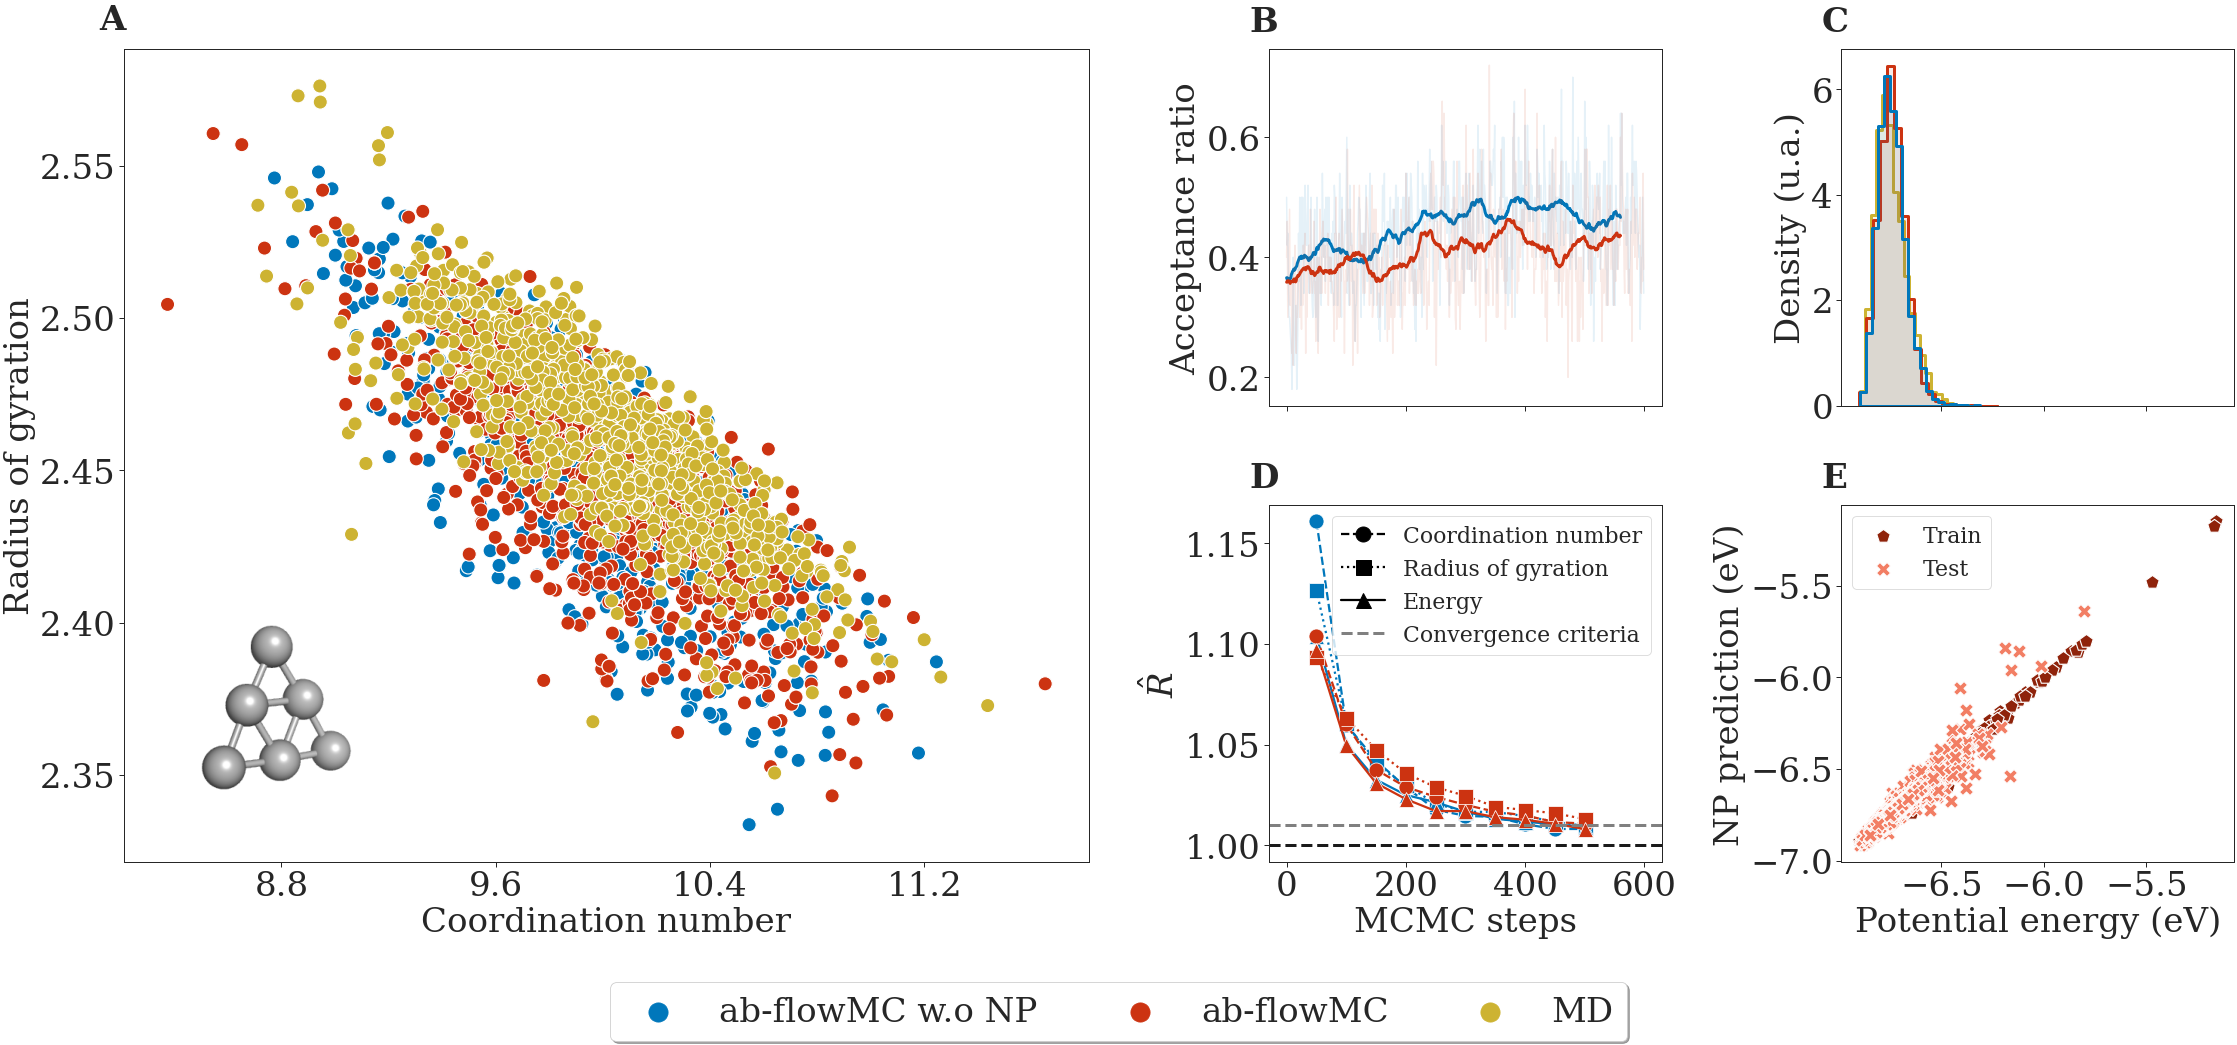

In [53]:
set_plot_figure_1(
    cvs_is0,
    flow_samples_is0,
    accs_is0,
    rhat_is0,
    energies_is0,
    np_predictions_is0,
    0,
    model_colors,
    size_legend=22,
)
plt.tight_layout()
plt.savefig(path_to_save_figures+'figure_1_is0.png', 
            dpi=300, 
            facecolor='white',
            transparent=False)

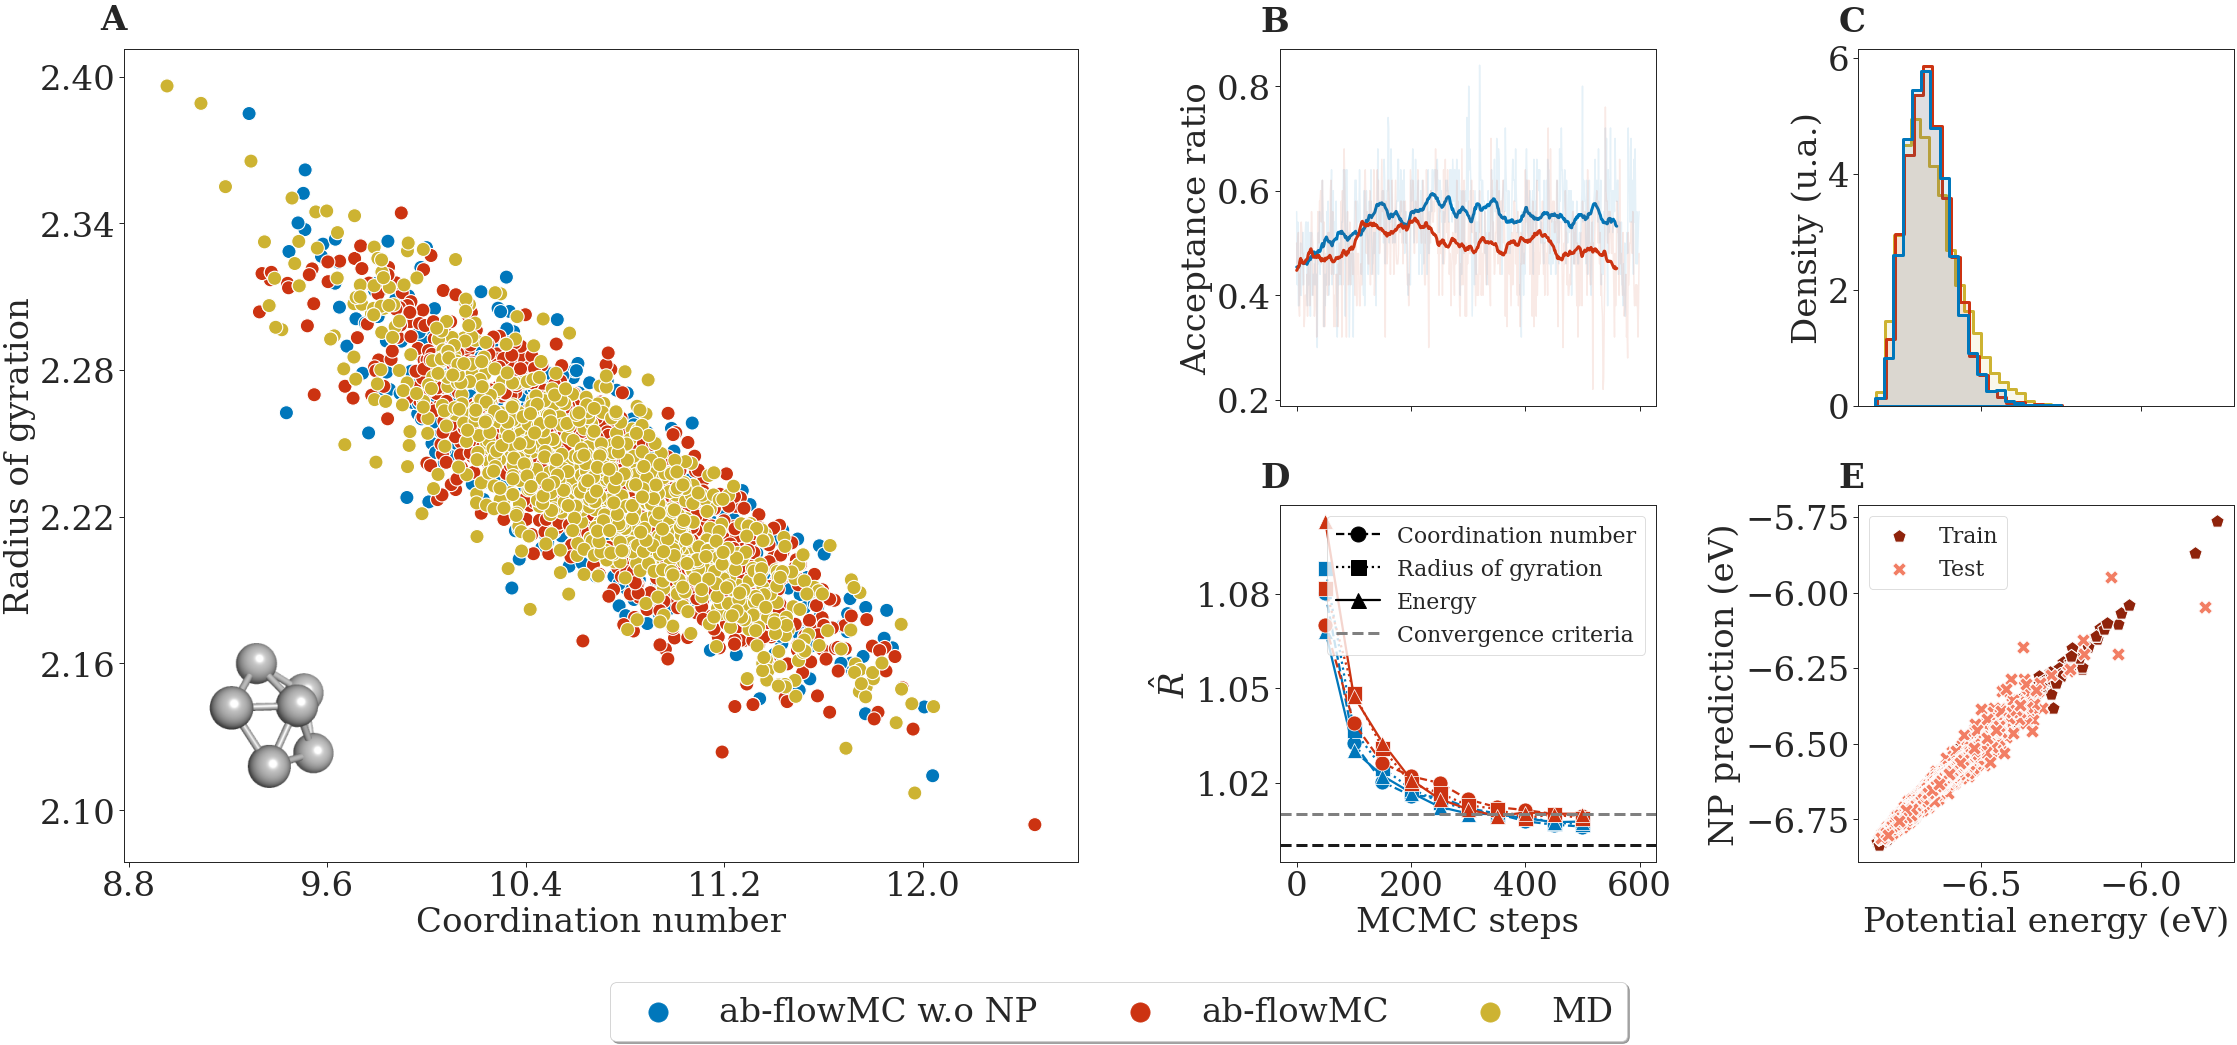

In [54]:
set_plot_figure_1(
    cvs_is1,
    flow_samples_is1,
    accs_is1,
    rhat_is1,
    energies_is1,
    np_predictions_is1,
    1,
    model_colors,
    size_legend=22,
)
plt.tight_layout()
plt.savefig(path_to_save_figures+'figure_1_is1.png', 
            dpi=300, 
            facecolor='white', 
            transparent=False)